In [1]:
import os
import sys
sys.path.append(os.path.join(os.path.dirname(os.getcwd()), 'src'))

from pathlib import Path
import cv2
import numpy as np
import matplotlib.pyplot as plt
from datetime import date
plt.rcParams["figure.figsize"] = (24,18)
from cv_utils import *

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from torchvision.datasets import CocoDetection
from torchvision import utils as vutils
from torch.utils.data import random_split
from shapely.geometry import Polygon
from matplotlib.patches import Polygon as pltPolygon
from PIL import Image
from tqdm import tqdm
torch.cuda.empty_cache()
torch.cuda.is_available()

True

In [2]:
data_path = os.path.join(os.path.dirname(os.getcwd()), 'data')
coco_dataset_path_1 = os.path.join(data_path, 'coco_datasets/real_train_pitch')
coco_dataset_path_2 = os.path.join(data_path, 'coco_datasets/synth_train_pitch')
dest_path=os.path.join(data_path, 'coco_datasets')
merge_dest_path = merge_coco_dataset(coco_dataset_path_1, coco_dataset_path_2,
                   dest_path=os.path.join(data_path, 'coco_datasets'))

In [30]:
class PitchSegmentationModel(nn.Module):
    def __init__(self):
        super(FootballPitchSegmentationModel, self).__init__()

        self.encoder = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        self.decoder = nn.Sequential(
            nn.Conv2d(16, 1, kernel_size=3, padding=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

In [42]:
class PitchDataset(Dataset):
    def __init__(self, image_folder, annotation_file, transform=None):
        self.image_folder = image_folder
        with open(annotation_file, 'r') as f:
            self.annotations = json.load(f)
        self.transform = transform

    def __len__(self):
        return len(self.annotations['annotations'])

    def __getitem__(self, idx):
        annotation = self.annotations['annotations'][idx]
        name = self.annotations['images'][idx]
        img_name = os.path.join(self.image_folder, str(name["file_name"]))
        image = Image.open(img_name).convert('RGB')

        segmentation = np.array(annotation['segmentation'][0], dtype=np.int32).reshape((-1, 2))
        mask = self.create_mask(image.size, [segmentation])

        if self.transform:
            image = self.transform(image)
        else:
            image = transforms.ToTensor()(image)
        mask = transforms.ToTensor()(mask)
        return image, mask

    def create_mask(self, size, polygons):
        mask = np.zeros((size[1], size[0]), dtype=np.uint8)
        cv2.polylines(mask, polygons, isClosed=True, color=1, thickness=1)
        mask = Image.fromarray(mask)
        mask = mask.resize((512, 288), Image.NEAREST)  # Resize the mask to match the model output size
        return mask

In [43]:
def iou_loss(pred, target, smooth=1e-5):
    intersection = (pred * target).sum()
    union = pred.sum() + target.sum() - intersection
    iou = (intersection + smooth) / (union + smooth)
    return 1 - iou

In [44]:
image_folder = os.path.join(merge_path_dest, "images")
annotation_file = os.path.join(merge_path_dest, "annotations", "instances_default.json")
transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.Resize((576, 1024)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])
dataset = PitchDataset(image_folder=image_folder, annotation_file=annotation_file, transform=transform)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
data_loader = DataLoader(dataset, batch_size=8, shuffle=True)
model = PitchSegmentationModel().to(device)
criterion = iou_loss
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
epochs = 5
for epoch in range(epochs):
    model.train()
    total_loss = 0.0

    for inputs, targets in tqdm(data_loader):
        inputs, targets = inputs.to(device), targets.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    average_loss = total_loss / len(data_loader)
    print(f'Epoch [{epoch + 1}/{epochs}], Loss: {average_loss}')


cuda


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 78/78 [01:02<00:00,  1.24it/s]


Epoch [1/5], Loss: 0.9999951727879353


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 78/78 [01:03<00:00,  1.23it/s]


Epoch [2/5], Loss: 0.9999951490989099


...

Epoch [3/5], Loss: 0.9999951513913962


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 78/78 [01:02<00:00,  1.24it/s]


Epoch [4/5], Loss: 0.9999951529197204


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 78/78 [01:02<00:00,  1.24it/s]

Epoch [5/5], Loss: 0.9999951529197204


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


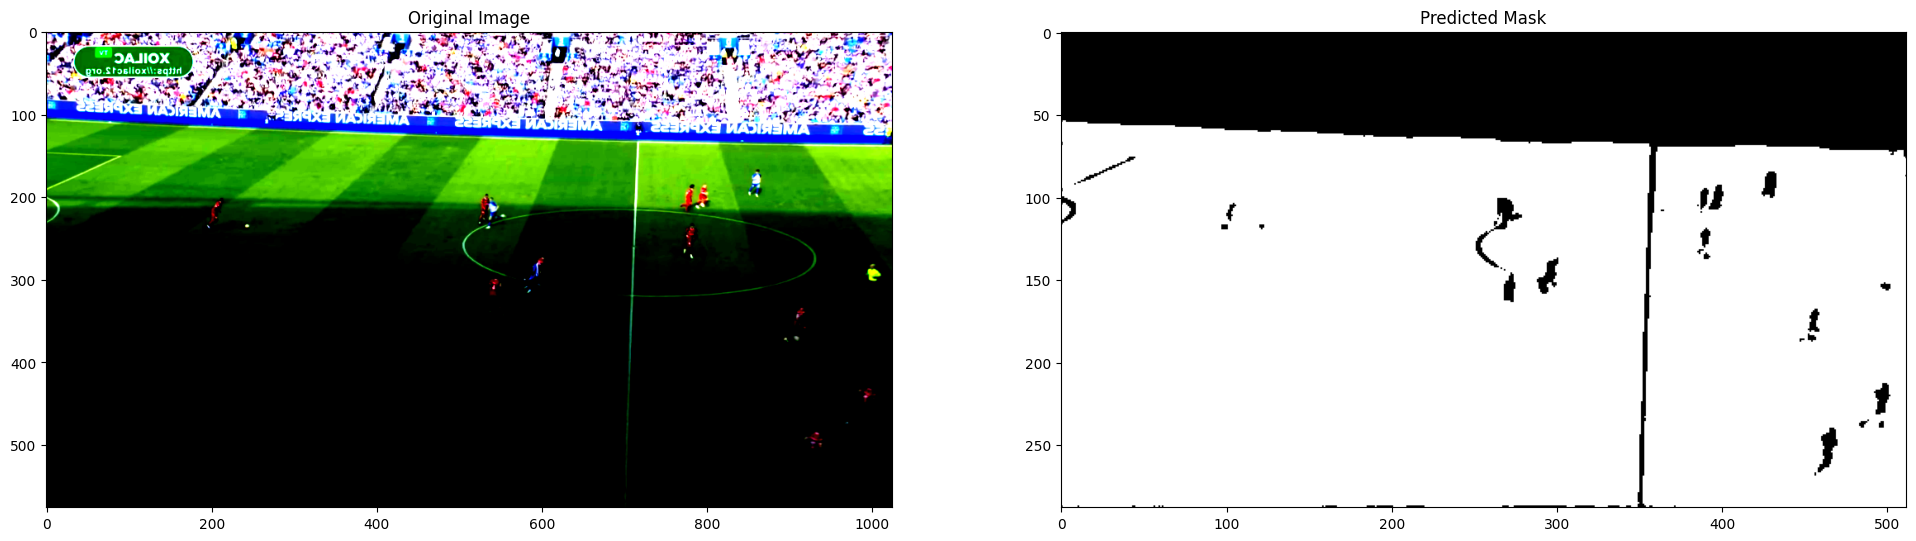

In [51]:
model.eval()

with torch.no_grad():
    test_image = Image.open('D:/Football-analysis/data/coco_datasets/real_train/images/000000000001.png').convert('RGB')
    test_image = transform(test_image).unsqueeze(0).to(device)
    predicted_mask = model(test_image)

predicted_mask_binary = (predicted_mask < 0.5).float().squeeze().cpu().numpy()
test_image_np = test_image.squeeze().permute(1, 2, 0).cpu().numpy()

plt.subplot(1, 2, 1)
plt.imshow(test_image_np)
plt.title("Original Image")

plt.subplot(1, 2, 2)
plt.imshow(predicted_mask_binary, cmap='gray')
plt.title("Predicted Mask")

plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


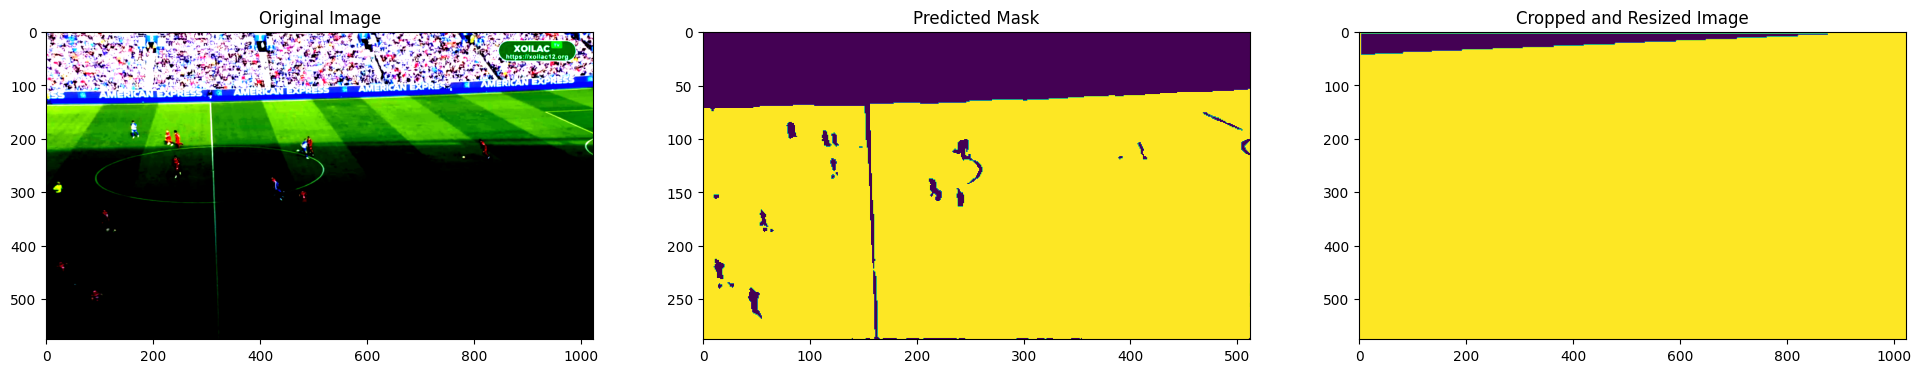

In [113]:
from torchvision.transforms import functional as F

model.eval()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

with torch.no_grad():
    test_image_path = 'D:/Football-analysis/data/coco_datasets/real_train/images/000000000001.png'
    test_image = Image.open(test_image_path).convert('RGB')
    test_image_tensor = transform(test_image).unsqueeze(0).to(device)
    predicted_mask = model(test_image_tensor)

predicted_mask_binary = (predicted_mask < 0.5).float().squeeze().cpu().numpy()
test_image_np = test_image_tensor.squeeze().permute(1, 2, 0).cpu().numpy()

contours, hierarchy = cv2.findContours((predicted_mask_binary * 255).astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
largest_contour = max(contours, key=cv2.contourArea)
convex_hull = cv2.convexHull(largest_contour)
rect = cv2.boundingRect(largest_contour)

contours, hierarchy = cv2.findContours((predicted_mask_binary * 255).astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
largest_contour = max(contours, key=cv2.contourArea)

# Draw contours
contour_image = np.zeros_like(predicted_mask_binary, dtype=np.uint8)
cv2.drawContours(contour_image, [largest_contour], -1, 1, thickness=cv2.FILLED)

# Draw convex hull
convex_hull = cv2.convexHull(largest_contour)
cv2.drawContours(contour_image, [convex_hull], -1, 1, thickness=cv2.FILLED)

# Draw bounding box
rect = cv2.boundingRect(largest_contour)
cv2.rectangle(contour_image, (rect[0], rect[1]), (rect[0] + rect[2], rect[1] + rect[3]), 1, thickness=2)

# Crop to bounding box
cropped_image = contour_image[rect[1]:rect[1] + rect[3], rect[0]:rect[0] + rect[2]]

# Resize to original size
resized_image = cv2.resize(cropped_image, (test_image_np.shape[1], test_image_np.shape[0]))

plt.subplot(1, 3, 1)
plt.imshow(test_image_np)
plt.title("Original Image")

plt.subplot(1, 3, 2)
plt.imshow(predicted_mask_binary)
plt.title("Predicted Mask")

plt.subplot(1, 3, 3)
plt.imshow(resized_image)
plt.title("Cropped and Resized Image")

plt.show()